###Ejercicio 1):
 Utilice lo aprendido en los trabajos prácticos previos (uso de biopython para obtenersecuencias, BLAST y el “parser del mismo”) para:

 i) obtener 10 secuencias pertenecientes a una misma familia y

 ii) Alinearlas y obtener la correspondiente matriz de puntaje / identidad

 Analice si la matriz es (o no) simetrica

 Compare matrices utilizando diferentes puntajes que le otorga BLAST (Bit Score, Identidad, E-Value)

Lista de 10 proteinas CYP1A1 de distintas especies

In [2]:
!pip install logomaker
!pip install biopython

In [3]:
from Bio import SeqIO, pairwise2
from Bio.Align import substitution_matrices
import numpy as np
import pandas as pd
import copy
from Bio import Phylo
from io import StringIO
import matplotlib.pyplot as plt
import logomaker


/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [4]:
#Instalar dependencias
!apt-get install mafft -y
!pip install biopython logomaker matplotlib

#Importar librerías
from Bio import SeqIO, pairwise2, Phylo
from Bio.Align import substitution_matrices
from io import StringIO
import logomaker
import pandas as pd
import matplotlib.pyplot as plt


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-lato libauthen-sasl-perl libclone-perl libdata-dump-perl
  libencode-locale-perl libfile-listing-perl libfont-afm-perl
  libhtml-form-perl libhtml-format-perl libhtml-parser-perl
  libhtml-tagset-perl libhtml-tree-perl libhttp-cookies-perl
  libhttp-daemon-perl libhttp-date-perl libhttp-message-perl
  libhttp-negotiate-perl libio-html-perl libio-socket-ssl-perl
  liblwp-mediatypes-perl liblwp-protocol-https-perl libmailtools-perl
  libnet-http-perl libnet-smtp-ssl-perl libnet-ssleay-perl libruby3.0
  libtry-tiny-perl liburi-perl libwww-perl libwww-robotrules-perl lynx
  lynx-common netbase perl-openssl-defaults rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration
Suggested packages:
  libdigest-hmac-perl libgssapi-perl libcrypt-ssleay-perl libsub-name-perl
  libbusiness-isbn-perl libauthe

In [5]:
!wget ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
!tar -xzf ncbi-blast-*-x64-linux.tar.gz
!mv ncbi-blast-*/bin/* /usr/local/bin/

--2025-10-01 02:20:49--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/LATEST/ncbi-blast-*-x64-linux.tar.gz
           => ‘.listing’
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.11, 130.14.250.12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /blast/executables/blast+/LATEST ... done.
==> PASV ... done.    ==> LIST ... done.

.listing                [ <=>                ]   2.62K  --.-KB/s    in 0.02s   

2025-10-01 02:20:49 (142 KB/s) - ‘.listing’ saved [2678]

Removed ‘.listing’.
--2025-10-01 02:20:49--  ftp://ftp.ncbi.nlm.nih.gov/blast/executables/blast%2B/LATEST/ncbi-blast-2.17.0%2B-x64-linux.tar.gz
           => ‘ncbi-blast-2.17.0+-x64-linux.tar.gz’
==> CWD not required.
==> PASV ... done.    ==> RETR ncbi-blast-2.17.0+-x64-linux.tar.gz ... done.
Length: 296006458 (282M)

ncbi-blas

In [7]:
import pandas as pd
def cargar_blosum60(path="blosum60.txt"):
    with open(path) as f:
        lines = [line.strip() for line in f if not line.startswith("#")]

    header = lines[0].split()
    data = []
    index = []

    for line in lines[1:]:
        parts = line.split()
        index.append(parts[0])
        data.append([int(x) for x in parts[1:]])

    df = pd.DataFrame(data, index=index, columns=header)
    return df

# Cargar matriz
blosum60_df = cargar_blosum60()

# Mostrar parte de la matriz

def df_to_blosum_dict(df):
    matrix = {}
    for i in df.index:
        for j in df.columns:
            score = df.at[i, j]
            matrix[(i, j)] = score
            matrix[(j, i)] = score  # aseguramos simetría
    return matrix


blosum_dict = df_to_blosum_dict(blosum60_df)


**def blast_two_seqs**

    """
    Hace BLASTp local entre dos secuencias proteicas y devuelve métricas clave.

    Args:
      seq_query (str): Secuencia proteica que será la consulta.
      seq_db (str): Secuencia proteica que será la base de datos.
      id_query (str): ID para la secuencia consulta.
      id_db (str): ID para la secuencia base de datos.
      temp_dir (str): Carpeta temporal para archivos.

    Returns:
      tuple: (evalue, bitscore, pident) del mejor hit.
             Si no hay hits, devuelve (None, None, None).
    """

In [8]:
import os

def blast_two_seqs(seq_query, seq_db, id_query="query", id_db="db", temp_dir="temp_blast"):
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)

    # Crear archivo fasta para consulta
    query_path = os.path.join(temp_dir, "query.fasta")
    with open(query_path, "w") as f:
        f.write(f">{id_query}\n{seq_query}\n")

    # Crear archivo fasta para base de datos (es una sola secuencia)
    db_path = os.path.join(temp_dir, "db.fasta")
    with open(db_path, "w") as f:
        f.write(f">{id_db}\n{seq_db}\n")

    # Crear base de datos local
    db_name = os.path.join(temp_dir, "db")
    cmd_make_db = f"makeblastdb -in {db_path} -dbtype prot -out {db_name} -logfile /dev/null"
    os.system(cmd_make_db)

    # Ejecutar blastp obteniendo evalue bitscore pident
    output_path = os.path.join(temp_dir, "blast_out.txt")
    cmd_blast = (
        f"blastp -query {query_path} -db {db_name} "
        f"-out {output_path} -outfmt '6 evalue bitscore pident' "
        f"-max_target_seqs 1 -num_threads 1"
    )
    os.system(cmd_blast)

    # Leer resultado
    evalue, bitscore, pident = None, None, None
    if os.path.exists(output_path):
        with open(output_path) as f:
            line = f.readline().strip()
            if line:
                evalue_str, bitscore_str, pident_str = line.split("\t")
                evalue = float(evalue_str)
                bitscore = float(bitscore_str)
                pident = float(pident_str)

    return evalue, bitscore, pident


#Obtenemos 10 secuencias de la familia quinasa

In [9]:

from Bio import Entrez, SeqIO

Entrez.email = "joaquinsalva03@gmail.com"

# Paso 1: buscar proteínas asociadas a una familia en NCBI Protein
handle = Entrez.esearch(
    db="protein",
    term="Protein kinase[Protein Name]",
    retmax=10  # cantidad de secuencias a traer
)
record = Entrez.read(handle)
handle.close()
lista_quinasas_id = record["IdList"]
print(lista_quinasas_id)

print("IDs encontrados:", record["IdList"])

# Paso 2: bajar las secuencias en formato fasta
handle = Entrez.efetch(
    db="protein",
    id=",".join(record["IdList"]),
    rettype="fasta",
    retmode="text"
)

# Paso 3: parsear a strings y guardarlas en una lista
lista_quinasas = [str(rec.seq) for rec in SeqIO.parse(handle, "fasta")]
handle.close()

print("Número de secuencias:", len(lista_quinasas))



['3068627628', '3068349286', '3068345775', '3068339861', '3068336351', '3068334329', '3068331069', '1696737072', '3065047616', '3065037855']
IDs encontrados: ['3068627628', '3068349286', '3068345775', '3068339861', '3068336351', '3068334329', '3068331069', '1696737072', '3065047616', '3065037855']
Número de secuencias: 10


In [10]:
def guardar_lista_fasta(lista_secuencias, output_path="secuencias.fasta", prefix="Prot_"):
    with open(output_path, "w") as f:
        for i, seq in enumerate(lista_secuencias):
            f.write(f">{prefix}{i}\n")
            f.write(f"{seq}\n")
guardar_lista_fasta(lista_quinasas, "quinasas.fasta")


### Cargamos las matriz Blosum 60

In [11]:
# Cargar matriz
blosum60_df = cargar_blosum60()
def obtener_matriz_blast_scores(lista_proteinas):
    # Inicializar matriz
    n = len(lista_proteinas)
    evalue_matrix, bitscore_matrix, pident_matrix = np.zeros((n, n)), np.zeros((n, n)),np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            seq1 = lista_proteinas[i]
            seq2 = lista_proteinas[j]
            evalue, bitscore, pident = blast_two_seqs(seq1, seq2)
            evalue_matrix[i][j]= evalue
            bitscore_matrix[i][j] = bitscore
            pident_matrix[i][j]  =  pident


    maximo = np.nanmax(evalue_matrix)
    evalue_matrix = np.nan_to_num(evalue_matrix, nan=maximo)

    bitscore_matrix = np.nan_to_num(bitscore_matrix, nan=0)

    pident_matrix = np.nan_to_num(pident_matrix, nan=0)
    return evalue_matrix, bitscore_matrix, pident_matrix

Ejercicio 2): Programe un algoritmo que dada una matriz de distancias construya un árbol guía.Utilice el mismo para trabajar con las diferentes matrices obtenidas a partir de los puntajes deBLAST y analice los resultados de manera comparativa.

# De la matriz al arbol guia

## De la matriz al arbol

Tomamos la matriz de distancias y, reduciendo su dimension, calculamos el agrupamiento de nodos del arbol guia

Para esto tenemos que:

* Tener una matriz de distancias donde las columnas y las filas son un conjunto de secuencias (que lo llamamos C).
* encontrar el maximo valor de la matriz
  junto con sus coordenadas
  maximo = distancia (A,B), con A,B en C, y su distancia el maximo score, es decir, mayor parecido entre si.  
* Quito las filas y columnas donde se vea distancias de A o B a otra secuencia X
* Armo una fila que sea distancia ((AB, X)

De esta manera, evitamos recalcular toda la matriz de distancia, donde lo que nos interesa modificar es aquellas filas, columnas que se vean afectadas

## Graficar el arbol guia

Encontrar minimo y maximo nos permiten personalizar la matriz que hace el arbol guia segun si queremos hacerlo por e-value o pident.

Actualizar matriz reduce la dimension de la matriz, actualizadola al alineamiento multiple que se tomo de acuerdo al minimo o maximo.


In [12]:
import numpy as np

def imprimir_matriz(matriz, etiquetas):
    print("\nMatriz actual:")
    df = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)
    display(df)
    return

def encontrar_maximo(matriz):
    n = len(matriz)
    max_val = float('-inf')  # empezamos desde -infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] > max_val:
                max_val = matriz[i][j]
                coords = (i, j)
    return coords, max_val

def encontrar_minimo(matriz):
    n = len(matriz)
    min_val = float('inf')  # empezamos desde infinito
    coords = (-1, -1)
    for i in range(n):
        for j in range(i+1, n):  # triángulo superior
            if matriz[i][j] < min_val:
                min_val = matriz[i][j]
                coords = (i, j)
    return coords, min_val


def calcular_distancia_promedio(matriz, i, j):
    n = len(matriz)
    nueva_fila = []
    for k in range(n):
        if k != i and k != j:
            d = (matriz[i][k] + matriz[j][k]) / 2
            nueva_fila.append(d)
    return nueva_fila

def actualizar_matriz(matriz, etiquetas, i, j):
    # Unimos etiquetas como una string (sin espacios si lo querés tipo Newick)
    nueva_etiqueta = f"({etiquetas[i]},{etiquetas[j]})"

    nueva_fila = calcular_distancia_promedio(matriz, i, j)

    # Eliminar i y j (mayor índice primero)
    indices = sorted([i, j], reverse=True)
    for idx in indices:
        matriz = np.delete(matriz, idx, axis=0)
        matriz = np.delete(matriz, idx, axis=1)
        etiquetas.pop(idx)

    # Agregar nueva fila/columna
    matriz = np.vstack([matriz, nueva_fila])
    nueva_col = nueva_fila + [0.0]
    matriz = np.column_stack([matriz, nueva_col])
    etiquetas.append(nueva_etiqueta)

    return matriz, etiquetas


   ### armar_arbol_guia

    """
    Genera arbol en formato newick

    Args:
        matriz: matriz de puntajes de alineamientos todas con todas.
        etiquetas: Forma de identificar a cada secuencia que aparecera en el arbol
        tipo_score: Cual fue el criterio de agrupamiento (minimo e-value, maximo pident)
    """

In [13]:
def armar_arbol_guia(matriz, etiquetas, tipo_score):
      paso = 1
      while len(etiquetas) > 1:
#          imprimir_matriz(matriz, etiquetas)
          if tipo_score in ['bitscore', 'pident']:
              (i, j), max_val = encontrar_maximo(matriz)
           #   print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con {tipo_score} maximo {max_val}")

          if tipo_score == 'evalue':
              (i, j), min_val = encontrar_minimo(matriz)
   #           print(f"\nPaso {paso}: Agrupando '{etiquetas[i]}' y '{etiquetas[j]}' con evalue mínimo {min_val}")

          matriz, etiquetas = actualizar_matriz(matriz, etiquetas, i, j)
          paso += 1

    #  print("\nÁrbol final:", etiquetas[0])
      return etiquetas[0]


Miramos los distintos arboles guias que se generan de acuerdo a si los armamos por bitscore, pident o e-value

In [14]:
#Obtenemos las 3 matrices, una por tipo de score
evalue_matrix, bitscore_matrix, pident_matrix = obtener_matriz_blast_scores(lista_quinasas)
print(evalue_matrix)
print(bitscore_matrix)
print(pident_matrix)

labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_bitscore = armar_arbol_guia(bitscore_matrix, labels, 'bitscore')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_pident = armar_arbol_guia(pident_matrix, labels, 'pident')
labels = [ f"Prot {i}" for i in range(len(lista_quinasas))]
arbol_evalue = armar_arbol_guia(evalue_matrix, labels, 'evalue')

tree_bitscore = Phylo.read(StringIO(arbol_bitscore), "newick")
tree_pident = Phylo.read(StringIO(arbol_pident), "newick")
tree_evalue = Phylo.read(StringIO(arbol_evalue), "newick")


[[0.00e+000 2.01e-086 1.57e-100 5.76e-091 2.31e-094 7.54e-127 2.89e-106
  0.00e+000 6.80e-001 1.70e-001]
 [7.33e-098 1.48e-177 1.23e-090 1.72e-158 1.10e-092 7.05e-067 1.61e-097
  8.24e-092 1.10e-002 2.40e-002]
 [3.10e-112 2.43e-088 0.00e+000 8.15e-097 3.79e-094 2.00e-065 0.00e+000
  1.89e-103 5.90e-001 5.50e-001]
 [2.81e-099 1.72e-158 4.59e-091 8.52e-179 3.28e-093 1.11e-067 3.52e-098
  3.01e-093 1.00e-002 2.30e-002]
 [2.12e-101 9.05e-090 1.83e-093 9.03e-093 0.00e+000 4.48e-064 4.56e-095
  1.29e-092 5.20e-002 1.10e-002]
 [1.34e-116 6.78e-062 3.55e-061 2.98e-066 2.15e-059 0.00e+000 1.26e-063
  4.17e-070 1.70e-001 4.50e-001]
 [3.04e-113 1.38e-089 0.00e+000 2.30e-098 5.68e-094 2.93e-065 0.00e+000
  2.95e-104 4.80e-001 5.60e-001]
 [0.00e+000 6.56e-087 2.21e-098 9.14e-092 3.82e-092 3.97e-136 1.70e-102
  0.00e+000 7.20e-001 1.70e-001]
 [7.00e-001 2.50e-002 9.00e-001 1.60e-002 6.40e-002 1.70e-001 9.00e-001
  9.00e-001 0.00e+000 0.00e+000]
 [1.60e-001 5.40e-002 9.00e-001 3.50e-002 1.60e-002 4.4

## Arboles generados online por distintos modulos


### Muscle

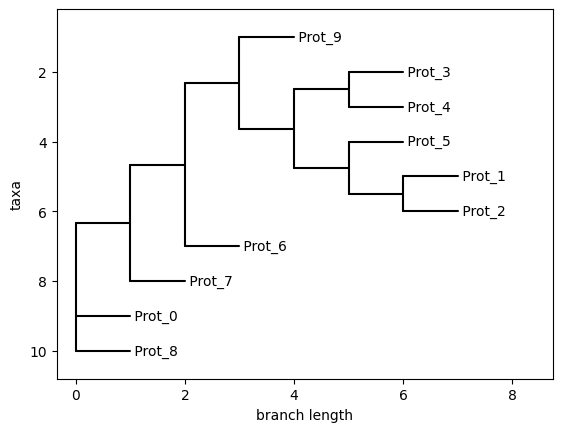

In [15]:
#Muscle
tree = Phylo.read("arbol_muscle.phylotree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Clustalw

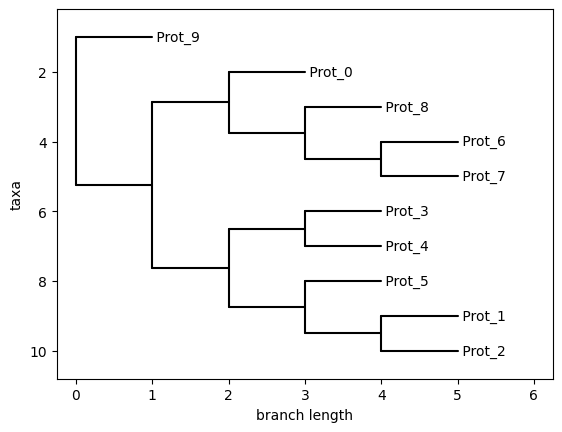

In [16]:
tree = Phylo.read("arbol_clustalw.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)


### Mafft

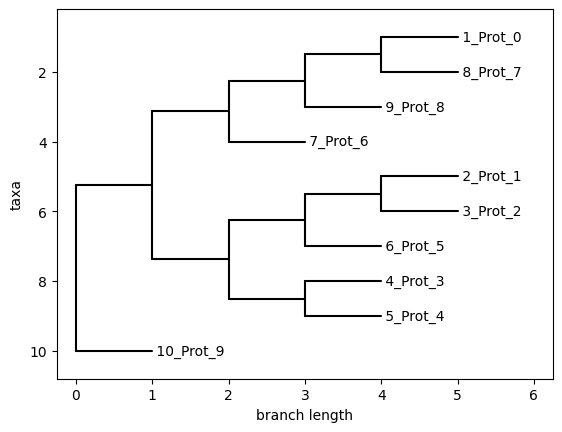

In [17]:
tree = Phylo.read("arbol_mafft.tree", "newick")

tree_no_lengths = copy.deepcopy(tree)
for clade in tree_no_lengths.find_clades():
    clade.branch_length = None

Phylo.draw(tree_no_lengths)

### Arboles guia generados por nuestro algoritmo

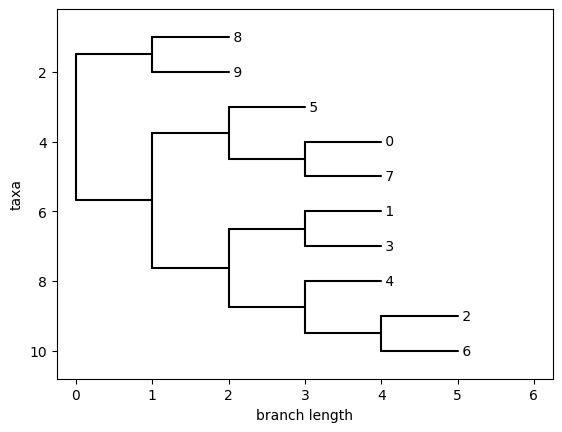

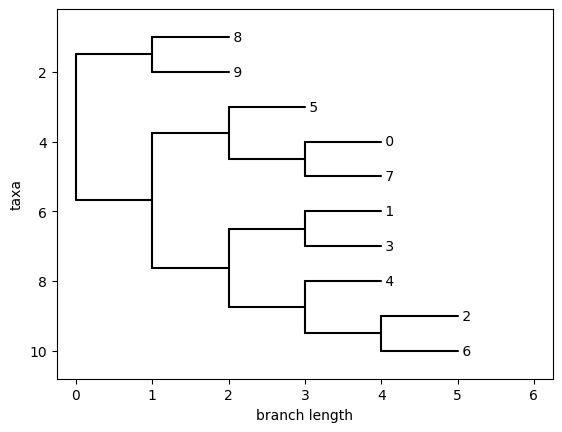

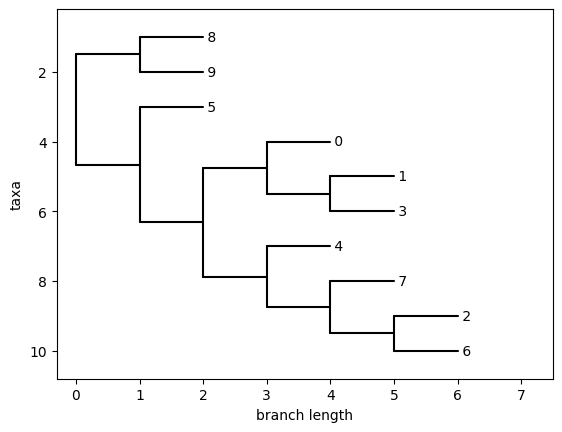

In [18]:

Phylo.draw(tree_bitscore)
Phylo.draw(tree_evalue)
Phylo.draw(tree_pident)

# Punto 3. Armamos el alineamiento a partir del arbol guia

Procedimiento:
1. Bajamos en el arbol y contemplamos los casos de alinear...
    * **secuencia con secuencia**

            hacemos el alineamiento de a pares con pairwise2
    * **secuencia con alineamiento de pares**
    
            miramos scores cruzados y nos quedamos con el maximo. Usamos esa "version" de la secuencia como template para agregarlo al AM, poniendo los interlineados necesarios para mantener el score
2. Repetimos a medida que vamos subiendo en el arbol


##Funciones necesarias para hacer un alineamiento multiple a partir de una lista de proteinas y un arbol guia


In [55]:
blosum62 = substitution_matrices.load("BLOSUM62")


def AP(seq1, seq2):
    "Realiza alineamiento de a pares"
    alignments = pairwise2.align.globalds(seq1, seq2, blosum62, -5, -1)
    return max(alignments, key=lambda x: x.score)

def expandir_secuencia(seq, secuencia_molde):
    "Extiende seq para conservar el alineamiento relativo con la secuencia molde"
    it = iter(seq)
    return "".join([next(it) if ch != "-" else "-" for ch in secuencia_molde])

def merge_alignments(align1, align2):
    "Toma 2 alineamientos, escoge el alineamiento de a pares de mayor score entre una secuencia de align1 y otra de align2."
    "Alinea dicho par y luego extiende las secuencias de sus alineamientos correspondientes para conservar el alineamiento relativo"

    seq1_sin_gaps = {sid: s.replace("-", "") for sid, s in align1.items()} #Obtenemos las secuencias sin gaps y colocamos en diccionarios
    seq2_sin_gaps = {sid: s.replace("-", "") for sid, s in align2.items()}
    best_score, best_pair, best_aln = -float("inf"), None, None #Inicializamos el mejor score, par y alineamiento
    for seq1_id, seq1 in seq1_sin_gaps.items(): #Iteramos sobre todos los posibles pares de secuencias
        for seq2_id, seq2 in seq2_sin_gaps.items():
            alineamiento_seqs_1_con_2 = AP(seq1, seq2)
            if alineamiento_seqs_1_con_2.score > best_score:
                best_score, best_pair, best_aln = alineamiento_seqs_1_con_2.score, (seq1_id, seq2_id), alineamiento_seqs_1_con_2
    seq1_aln, seq2_aln = best_aln.seqA, best_aln.seqB #Finalmente nos quedamos con los ids y alineamientos de las 2 secuencias de mayor score
    seq1_id, seq2_id = best_pair

#Inicializamos diccionario donde vamos a guardar el alineamiento nuevo, donde { Id de la secuencia : alineamiento de secuencia con el molde}
    new_alignment = {}
    for seq_id, s in align1.items():
        new_alignment[seq_id] = seq1_aln if seq_id==seq1_id else expandir_secuencia(s, seq1_aln)
    for seq_id, s in align2.items():
        new_alignment[seq_id] = seq2_aln if seq_id==seq2_id else expandir_secuencia(s, seq2_aln)
    return new_alignment


def AM(lista_secuencias, lista_ids, arbol_guia):
    "Dada una lista de proteinas e ids, las alinea recursivamente segun el arbol guia"

    tree = Phylo.read(StringIO(arbol_guia), "newick")#Lo leemos al arbol
    hojas = tree.get_terminals() #Tomamos los nodos hoja (al principio cada secuencia es una nodo)

    if len(hojas) != len(lista_ids):
        raise ValueError("Hojas y secuencias no coinciden")

    for hoja, id_real in zip(hojas, lista_ids):
        hoja.name = id_real
    secuencias_dict = {id_: seq for id_, seq in zip(lista_ids, lista_secuencias)}

    def recorrer(clade):
        if clade.is_terminal():
            return {clade.name: secuencias_dict[clade.name]}
        else:
            children = [recorrer(child) for child in clade.clades]
            aln = children[0]
            for other in children[1:]:
                aln = merge_alignments(aln, other)
            return aln
    return recorrer(tree.root)

# Árbol Newick de ejemplo
#arbol_ejemplo = "(" + ",".join(lista_quinasas_id) + ");"
#resultado_AM = AM(lista_quinasas, lista_quinasas_id, arbol_ejemplo)


### Funcion auxiliar para convertir un diccionario resultante de un alineamiento multiple (los significados son las secuencias con los gaps incluidos) en un dataframe de frecuencias de aminoacidos por posicion del alineamiento

In [23]:
def alignment_to_frequency_df(alignment_dict):
    seqs = list(alignment_dict.values()) #lista con las secuencias
    longitud_alineamiento = len(seqs[0])
    alphabet = sorted(set("".join(seqs))) #conjunto de aminoacidos presentes en el alineamiento
    freq_df = pd.DataFrame(0, index=range(longitud_alineamiento), columns=alphabet, dtype=float) #creamos el dataframe
    for pos in range(longitud_alineamiento):
        column_chars = [seq[pos] for seq in seqs] #Hago una lista con los aminoacidos o gap que aparecen en esa posicion en todas las secuencias
        for char in column_chars:
            freq_df.loc[pos, char] += 1 #sumo una aparicion a esa letra
    freq_df = freq_df / len(seqs)
    freq_df.drop(columns = ['-'])
    return freq_df

## Obtener AM toma un path de proteinas y devuelve:
  - dfs_nuestros: lista con un dataframe de frecuencias por posicion del alineaminento multiple por cada tipo de score (evalue, bitscore, pident).

  - df_mafft_freq : el mismo tipo de dataframe pero obtenido con el alineamiento de MAFFT.
### Plotear Logos grafica el logo de un dataframe de frecuencias por posicion

In [73]:
def obtener_AM(path_proteinas):
  #Obtenemos las secuencias del fasta
  secuencias = list(SeqIO.parse(path_proteinas, "fasta"))
  lista_proteinas = [str(rec.seq) for rec in secuencias]
  lista_ids = [ f"Prot {i}" for i in range(len(lista_proteinas))]

  #-----------------------MAFFT---------------------------
  #Computamos alineamiento multiple con MAFFT
  !mafft --auto --op 5 --ep 1   {"quinasas.fasta"} > alineamiento_mafft.fasta

  #Leemos el alineamiento
  alineamiento_mafft = list(SeqIO.parse("alineamiento_mafft.fasta", "fasta"))
  #Guardamos las secuencias en un dataframe y preparamos para plotear en un logo
  dict_mafft = {rec.id: str(rec.seq) for rec in alineamiento_mafft}
  df_mafft_freq = alignment_to_frequency_df(dict_mafft)

  #-------------NUESTRO ALINEAMIENTO--------------------
  #Computamos matrices de scores con Blast
  evalue_matrix, bitscore_matrix, pident_matrix = obtener_matriz_blast_scores(lista_proteinas)
  scores = ['evalue', 'bitscore', 'pident']
  dfs_nuestros = []
  alineamientos_multiples_nuestros = []

  for i, score_matrix in enumerate([evalue_matrix, bitscore_matrix, pident_matrix]):
      lista_ids = [ f"Prot {i}" for i in range(len(lista_proteinas))] #Cada vez que armamos el arbol guia se modican los ids, por ello los redefinimos
      arbol = armar_arbol_guia(score_matrix, lista_ids, scores[i]) #armamos el arbol guia
      lista_ids = [ f"Prot {i}" for i in range(len(lista_proteinas))]


      resultado = AM(lista_proteinas, lista_ids, arbol) #Computamos alineamiento multiple con nuestro algoritmo
      alineamientos_multiples_nuestros.append(resultado)
      df = alignment_to_frequency_df(resultado) # Preparamos dataframe de frecuencias por posicion
      dfs_nuestros.append(df)

  return alineamientos_multiples_nuestros, dict_mafft, dfs_nuestros, df_mafft_freq

def plotear_logos(df_freq, titulo ):
    ancho = max(10, int(len(df_freq.columns) * 0.3))
    plt.figure(figsize=(50, 4))

    logomaker.Logo(df_freq, color_scheme='NajafabadiEtAl2017')
    plt.title(titulo)
    plt.xticks([])
    plt.yticks([])

    plt.show()

### Funciones que obtienen el contenido de informacion (columnas importantes) de un dataframe  y filtran dichas columnas, respectivamente.

In [60]:
import numpy as np
def contenido_de_informacion(df_frecuencias_por_posicion):
    """Devuelve un vector con el contenido de informacion por posición (Shannon)."""
    matriz_frecuencias_por_posicion = df_frecuencias_por_posicion.values #Pasamos de Dataframe a Numpy Array para manipular mas facil
    freqs = matriz_frecuencias_por_posicion / matriz_frecuencias_por_posicion.sum(axis=1, keepdims=True) # Normalizamos cada posicion
    entropy = -np.nansum(freqs * np.log2(freqs + 1e-9), axis=1) #Calculamos la entropia por cada posicion
    # Contenido De Informacion = log2(k) - entropía, k = tamaño alfabeto (21 si incluimos gap)
    k = df_frecuencias_por_posicion.shape[1]
    ic = np.log2(k) - entropy
    return ic

def filtrar_columnas_importantes(nuestros_dfs, df_MAFFT):
  "Filtramos de un dataframe las posiciones que no contienen suficiente informacion, segun un umbral"
  columnas_importantes_nuestros =[]
  umbral = 2.0

  #df_MAFFT = df_MAFFT.drop(columns = '-')
  ic_MAFFT = contenido_de_informacion(df_MAFFT) #Calculamos el contenido de informacion
  columnas_importantes_MAFFT = np.where(ic_MAFFT > umbral)[0] #Filtramos por el umbral
  df_con_columnas_importantes_MAFFT = df_MAFFT.iloc[columnas_importantes_MAFFT, :] #Indexamos en el dataframe en las columnas importantes
  for df in nuestros_dfs:
      #  df = df.drop(columns = '-')
        ic_DF = contenido_de_informacion(df)
        # Filtrar
        cols_DF = np.where(ic_DF > umbral)[0]
        df_con_columnas_importantes = df.iloc[cols_DF, :]
        columnas_importantes_nuestros.append(df_con_columnas_importantes)

  return columnas_importantes_nuestros, df_con_columnas_importantes_MAFFT


In [61]:
valores_blosum = list(blosum_dict.values())
mean_blosum = np.mean([ negativo for negativo in valores_blosum if negativo < 0])
print(mean_blosum)


-2.4563758389261743


outputhat23=16
treein = 0
compacttree = 0
stacksize: -1 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.490
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -5.00, +0.00, -1.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 10
done.

Progressive alignment ... 
STEP     9 /9 
done.
tbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 5.00, +1.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = -1000
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 10
Segment   1/  1    1-1318
STEP 005-007-0  rejected.
Converged.

done
dvtditr (aa) Version 7.490
alg=A, model=BLOSUM62, 5.00, +1.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Iterat

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

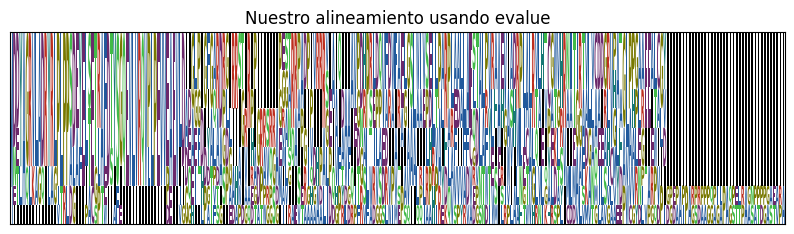

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

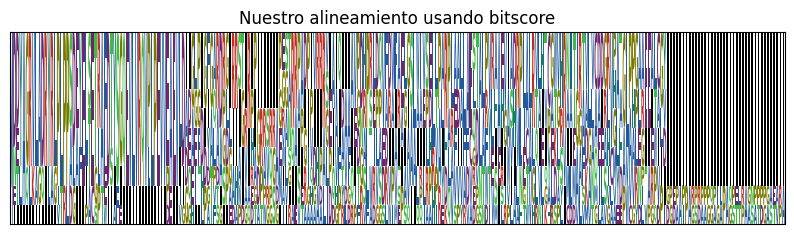

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

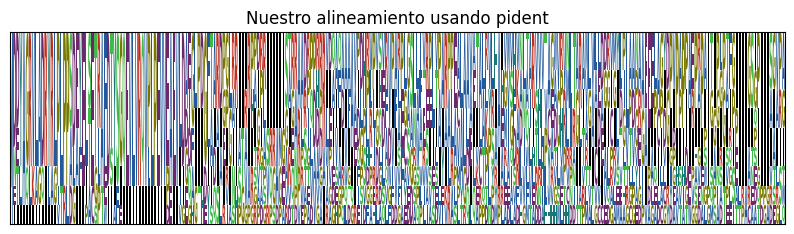

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

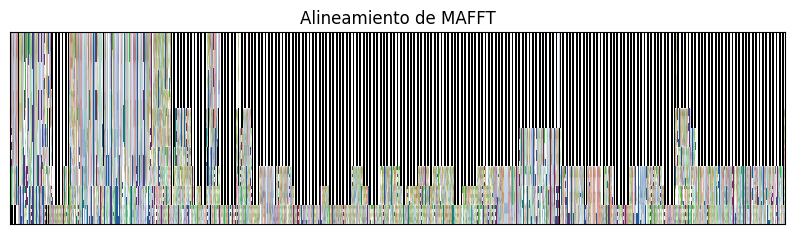

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

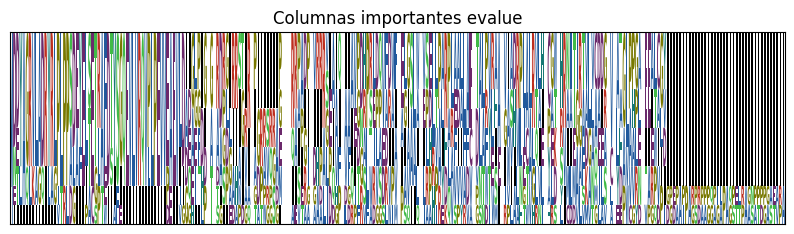

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

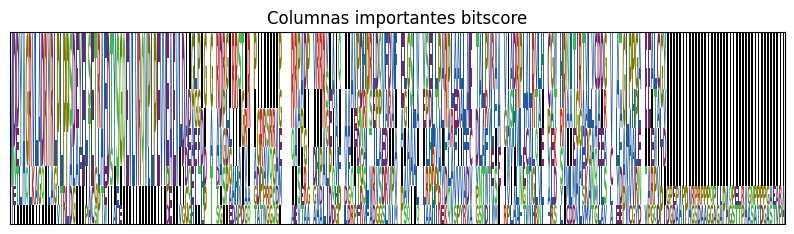

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

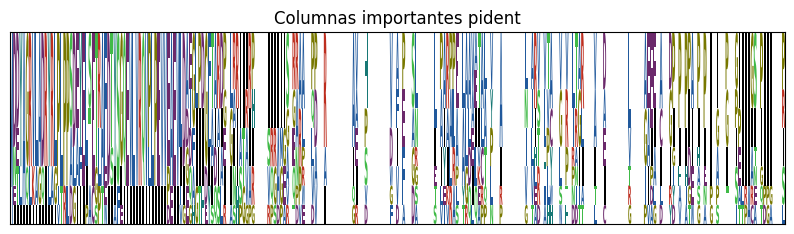

/usr/local/lib/python3.12/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 5000x400 with 0 Axes>

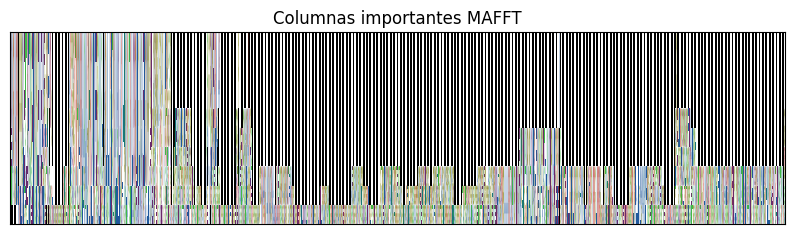

In [74]:
scores = ['evalue', 'bitscore', 'pident']
nuestros_alineamientos_multiples, alineamiento_multiple_MAFFT, dfs_quinasas_nuestros, df_quinasas_MAFFT = obtener_AM("quinasas.fasta")

for i, df in enumerate(dfs_quinasas_nuestros):
  plotear_logos(df, f'Nuestro alineamiento usando {scores[i]}')
plotear_logos(df_quinasas_MAFFT, 'Alineamiento de MAFFT')

col_importantes_quinasas_nuestros, col_importantes_quinasas_MAFFT = filtrar_columnas_importantes(dfs_quinasas_nuestros, df_quinasas_MAFFT)

for i, df in enumerate(col_importantes_quinasas_nuestros):
  plotear_logos(df, f'Columnas importantes {scores[i]}')
plotear_logos(col_importantes_quinasas_MAFFT, 'Columnas importantes MAFFT')



In [80]:
# Guardar un diccionario de secuencias alineadas en formato FASTA
def dict_to_fasta(seq_dict, output_file):
    with open(output_file, "w") as f:
        for header, sequence in seq_dict.items():
            f.write(f">{header}\n{sequence}\n")

for i,score in enumerate(['evalue', 'bitscore', 'pident']):
    dict_to_fasta(nuestros_alineamientos_multiples[i], f"quinasas_alineamiento_{score}.fasta")
dict_to_fasta( alineamiento_multiple_MAFFT, f"quinasas_alineamiento_mafft.fasta")


#Visualizamos los alineamientos Multiples en JalView


### Arbol usando el Evalue

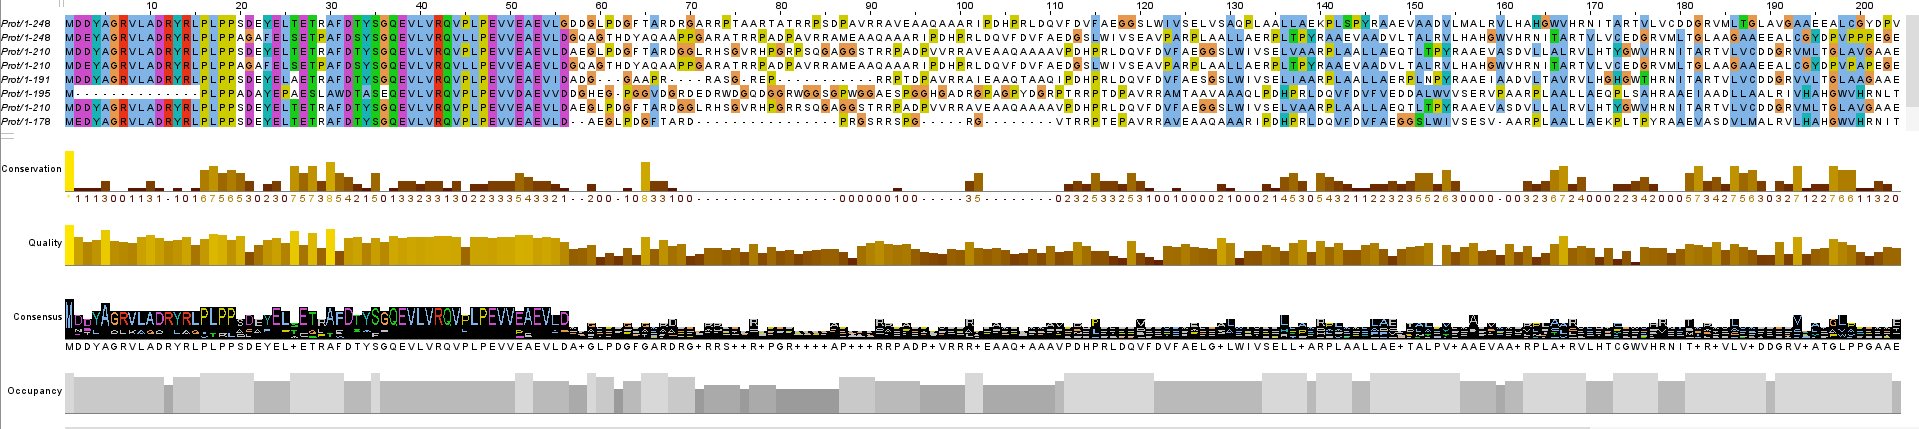

### Arbol usando bitscore

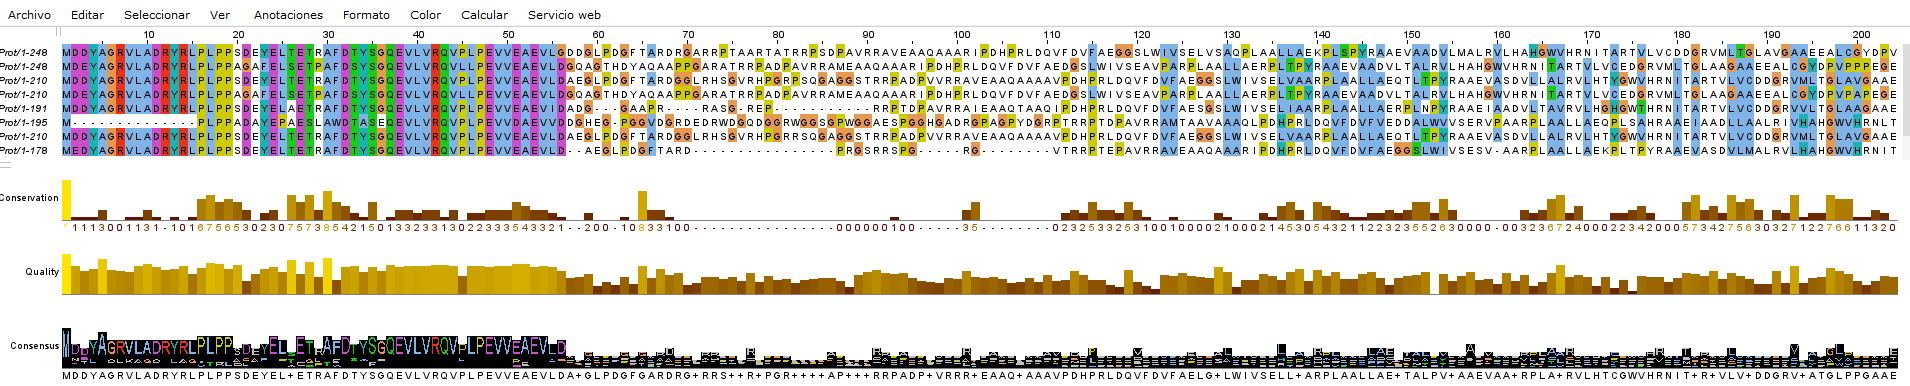

###Arbol usando porcentaje de identidad

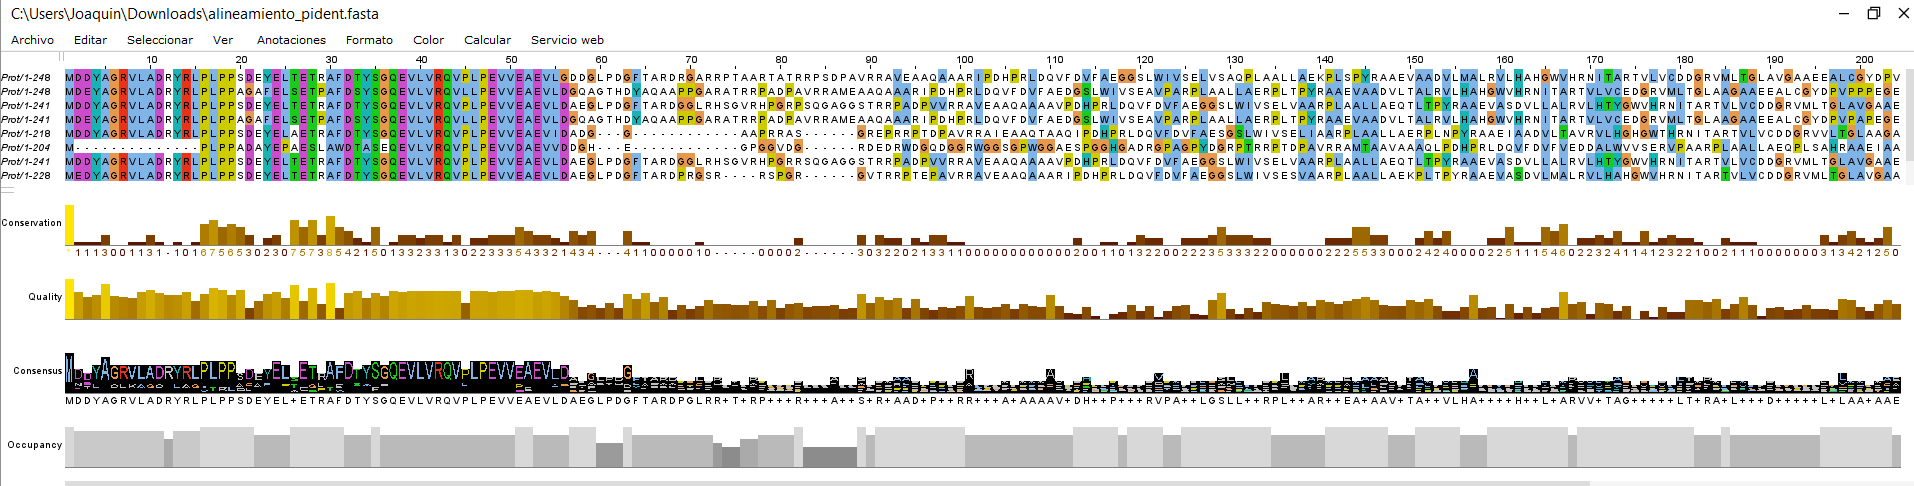

### Alineamiento multiple de MAFFT


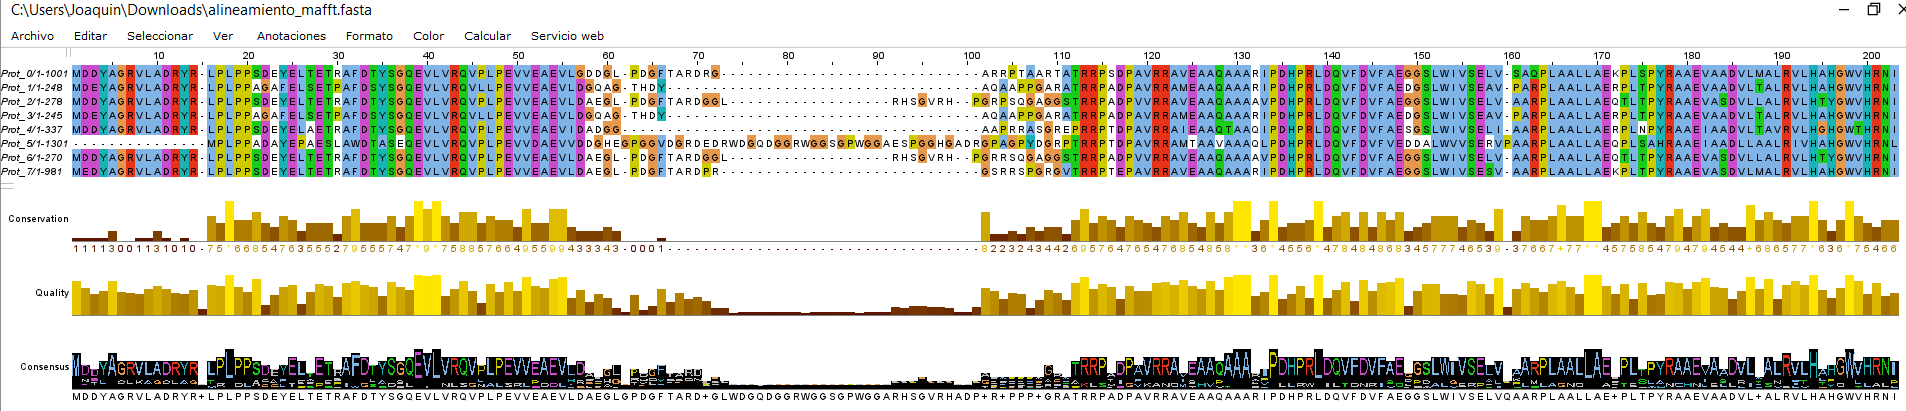

In [ ]:
df_proteinas_nuestro, df_proteinas_MAFFT = obtener_AM("proteins.fasta")

for i, df in enumerate(df_proteinas_nuestro):
  plotear_logos(df, f'Nuestro alineamiento usando {scores[i]}')
plotear_logos(df_proteinas_MAFFT, 'Alineamiento de MAFFT')

# Segundo conjunto de proteinas

In [78]:
import requests
uniprot_ids = [
    "P0AA25",   # E. coli Thioredoxin
    "Q10599",   # Humano Thioredoxin
    "A0A1F9VN03", # Bacteria Thioredoxin
    "A0A8D0LM87", # SH3 Pig
    "A0A3B4URS4", # SH3 Fish
    "A0A7M7HQ97", # SH3 Sea urchin
    "A0A5M4DGM1", # PDZ Bacteria
    "A0A3B6MWF7", # PDZ Wheat
    "A0A1X7TSZ0", # PDZ Sponge
    "A0A3D3BYH6"  # PDZ Gamma proteobacteria
]

# Función para descargar la secuencia de UniProt en formato FASTA
def fetch_uniprot_fasta(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    response = requests.get(url)
    if response.status_code == 200:
        return response.text
    else:
        print(f"No se pudo descargar {uniprot_id}")
        return None

# Descargar y guardar en un único archivo FASTA
with open("proteins.fasta", "w") as outfile:
    for uid in uniprot_ids:
        fasta = fetch_uniprot_fasta(uid)
        if fasta:
            outfile.write(fasta)

print("Archivo proteins.fasta creado con todas las secuencias.")
secuencias = list(SeqIO.parse("proteins.fasta", "fasta"))
lista_prots = [str(rec.seq) for rec in secuencias]
lista_prots_id = [ f"Prot {i}" for i,rec in enumerate(secuencias)]



Archivo proteins.fasta creado con todas las secuencias.


In [82]:
scores = ['evalue', 'bitscore', 'pident']
nuestros_alineamientos_multiples, alineamiento_multiple_MAFFT, dfs_proteinas_nuestros, df_proteinas_MAFFT = obtener_AM("proteins.fasta")

for i, df in enumerate(dfs_proteinas_nuestros):
  plotear_logos(df, f'Nuestro alineamiento usando {scores[i]}')
plotear_logos(df_proteinas_MAFFT, 'Alineamiento de MAFFT')

col_importantes_proteins_nuestros, col_importantes_proteins_MAFFT = filtrar_columnas_importantes(dfs_proteinas_nuestros, df_proteinas_MAFFT)

for i, df in enumerate(col_importantes_proteins_nuestros):
  plotear_logos(df, f'Columnas importantes {scores[i]}')
plotear_logos(col_importantes_proteins_MAFFT, 'Columnas importantes MAFFT')



outputhat23=16
treein = 0
compacttree = 0
stacksize: -1 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.490
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -5.00, +0.00, -1.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 10
done.

Progressive alignment ... 
STEP     9 /9 
done.
tbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 5.00, +1.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = -1000
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 10
Segment   1/  1    1-1318
STEP 005-007-0  rejected.
Converged.

done
dvtditr (aa) Version 7.490
alg=A, model=BLOSUM62, 5.00, +1.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Iterat

In [83]:
for i,score in enumerate(['evalue', 'bitscore', 'pident']):
    dict_to_fasta(nuestros_alineamientos_multiples[i], f"proteins_alineamiento_{score}.fasta")
dict_to_fasta( alineamiento_multiple_MAFFT, f"proteins_alineamiento_mafft.fasta")



### p ident
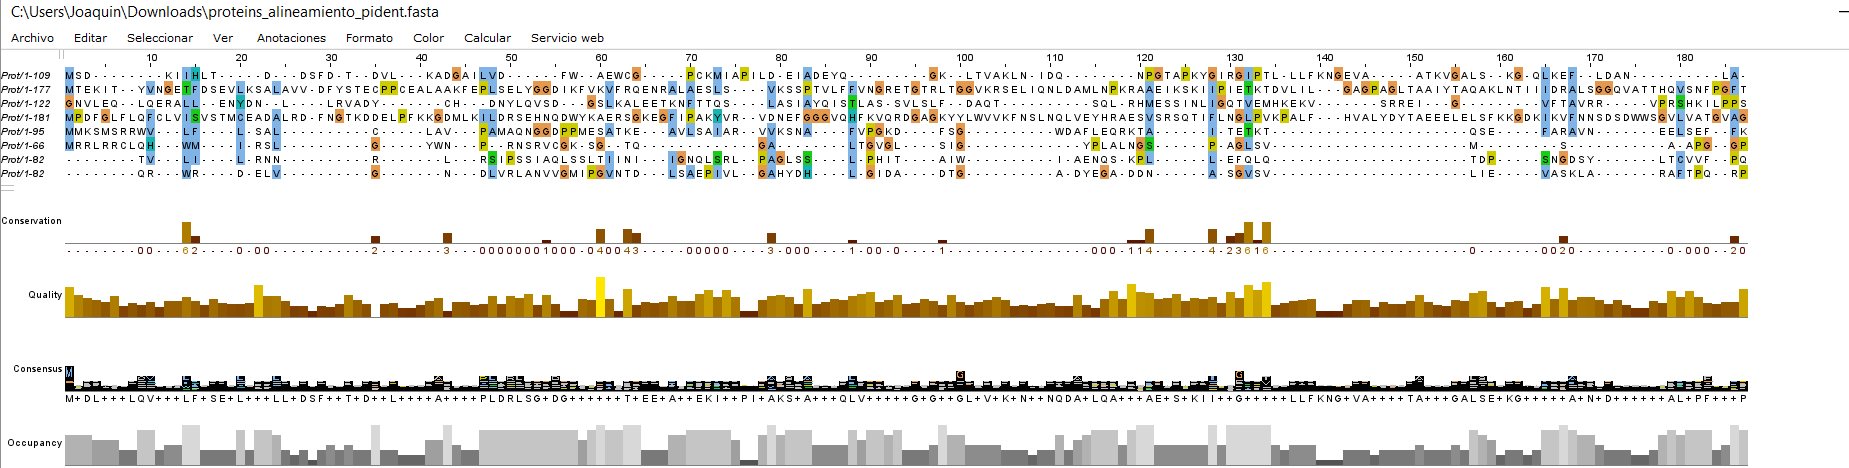

### Mafft
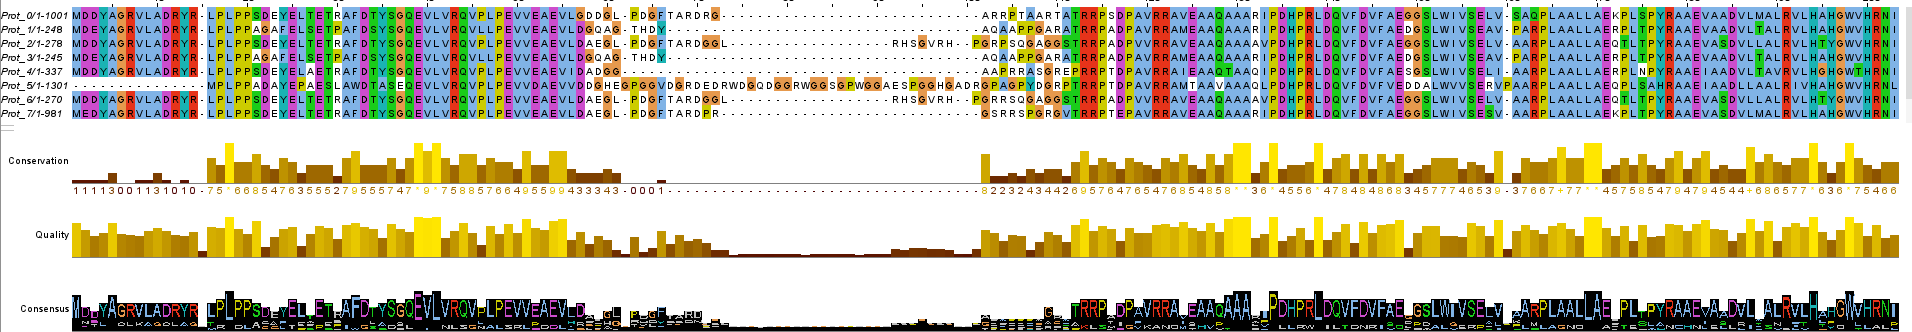